In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import ternary
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from mpl_toolkits.mplot3d import Axes3D
from Functions_OPEN_MINDEDNESS import *
from scipy.spatial.distance import pdist, squareform

## ABBIAMO INTRODOTTO L'OPEN MINDED INTERACTION

In [2]:
'''
def calculate_w(ind, storico_interaction , mu, t ):
    den = mu
    if t < mu:
        mu = t -1      
    
    somma = 0
   
    for t_prime in range( t - mu - 1 , t):  # range esclude il valore finale quindi metto t
        if t_prime not in storico_interaction[ind]:
            continue
        
        for int_type, dist in storico_interaction[ind][t_prime]:
            if int_type == +1:
                somma += dist
                continue
            if int_type == -1:
                somma += 1 - dist
                continue
            if int_type == 'om':
                somma += 1
                continue
        
    return somma / den


def interact_individuals(i1, i1_index, i2, eps, alpha , storico_interaction ,t , mu):
    #parameter definition 
    K = len(i1)  
    l = random.choice(range(K))
    o_ij = calculate_overlap(i1, i2)
    d = 1 - o_ij
   
    w = calculate_w(i1_index , storico_interaction , mu , t) 
    w = 1
    if d < 0.5:
        f_d = 0.5 + d
    if d >= 0.5: 
        f_d = 3/2 - d
   
        
    p_open_minded = w * f_d
    
    i1_new = i1.copy()
    resto = 0  
    # Calcolo della variazione delta
    if abs(i2[l] - i1[l]) > alpha:
        delta = alpha * np.sign(i2[l] - i1[l])
        
    else:
        delta = 0.5 * (i2[l] - i1[l])
    
    # DEFINE TWO KINDS OF INTERACTION POSSIBLE: OM OR NORMAL 
    if random.random() < p_open_minded:   #open minded interaction
        interaction_type = 'om'
        p_agree = 0.5
        if random.random() < p_agree:
            i1_new[l] += delta
            beta = delta  
        else:
            i1_new[l] -= delta
            beta = -delta
        
    else:      #NORMAL INTERACTION
        signo = random.choice([-1, +1])
        p_agree = min(1, max(0, o_ij + eps*signo))
        if random.random() < p_agree:
            interaction_type = +1
            i1_new[l] += delta
            beta = delta  
        else:
            interaction_type = -1
            i1_new[l] -= delta
            beta = -delta 
               
    # once calculate the variation of the vector, let's vary the vector 
      
    if i1_new[l] < 0: 
        resto += i1_new[l]
        i1_new[l] = 0
        
    if i1_new[l] >= 1:
       
        i1_new = np.zeros(len(i1_new))
        i1_new[l] = 1
        return i1_new, interaction_type,d   # se è più di 1 mettiamo vettore unitario e returniamo direttametne senza chiamare funzione di update 
    
    i1_last = update(np.array(i1_new) , l , beta - resto)
    
    
    return np.array(i1_last), interaction_type , d 


def evolve_population( pop_iniz , time , eps, alpha ,mu):
    pop_finale =  np.copy(pop_iniz)
    storico = {}
    storico_interaction = {}
    for t in range(time): 
        #print('TEMPO T = ' , t)
        #estraggo due individui casuali
        i1_index = random.randint(0, len(pop_iniz) - 1)
        i2_index = random.randint(0, len(pop_iniz) - 1)
        i1 , i2 = pop_finale[ i1_index ] , pop_finale[i2_index]
       # print('individuo 1 numero' , i1_index , 'interagisce con individuo 2 numero' , i2_index)
        if i1_index not in storico_interaction:
            storico_interaction[i1_index] = {}

        # più avanti, subito prima di appendere il risultato:
        storico_interaction[i1_index].setdefault(t, [])
        # ora posso fare
        i1_new , interaction , distance = interact_individuals(i1, i1_index, i2, eps, alpha , storico_interaction , t , mu)
        storico_interaction[i1_index][t].append([interaction, distance])
        
       # print('storico interaction',storico_interaction)
        pop_finale[i1_index] = i1_new
        storico[t] = np.copy(pop_finale)
    return pop_finale   , storico  , storico_interaction
'''

"\ndef calculate_w(ind, storico_interaction , mu, t ):\n    den = mu\n    if t < mu:\n        mu = t -1      \n    \n    somma = 0\n   \n    for t_prime in range( t - mu - 1 , t):  # range esclude il valore finale quindi metto t\n        if t_prime not in storico_interaction[ind]:\n            continue\n        \n        for int_type, dist in storico_interaction[ind][t_prime]:\n            if int_type == +1:\n                somma += dist\n                continue\n            if int_type == -1:\n                somma += 1 - dist\n                continue\n            if int_type == 'om':\n                somma += 1\n                continue\n        \n    return somma / den\n\n\ndef interact_individuals(i1, i1_index, i2, eps, alpha , storico_interaction ,t , mu):\n    #parameter definition \n    K = len(i1)  \n    l = random.choice(range(K))\n    o_ij = calculate_overlap(i1, i2)\n    d = 1 - o_ij\n   \n    w = calculate_w(i1_index , storico_interaction , mu , t) \n    w = 1\n    if d 

In [3]:
K = 3
N = 10
entropy_threshold = 1.2
popolazione_iniziale = generate_population(K,N, entropy_threshold)
o = calculate_total_overlap(popolazione_iniziale)                                           

In [4]:
t = 2000
eps = 0.1 
alpha = 0.0167
mu = 300
pop_finale   , storico  , storico_interaction = evolve_population( popolazione_iniziale , t , eps, alpha ,mu)

C:\Users\alice\anaconda3.1\Lib\site-packages\ternary\plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


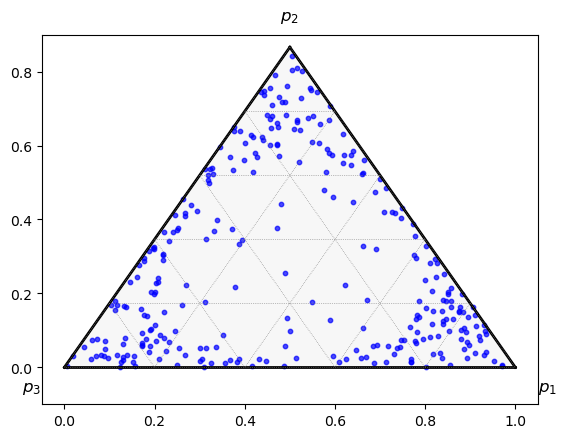

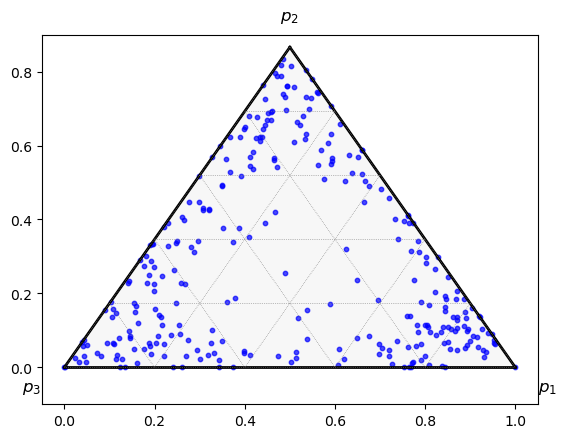

In [5]:
entropy_threshold =  1.2
alpha = 0.0167
N = 300
K=3
eps = 0.1

popolazione_iniziale = generate_population(K,N, entropy_threshold)
o = calculate_total_overlap(popolazione_iniziale)
pop_evoluta, storico, storico_interaction=evolve_population( popolazione_iniziale , t , eps, alpha ,mu)
plot_simplesso(popolazione_iniziale)
plot_simplesso(pop_evoluta)

FINAL COHESION VALUE 0.580606797262158


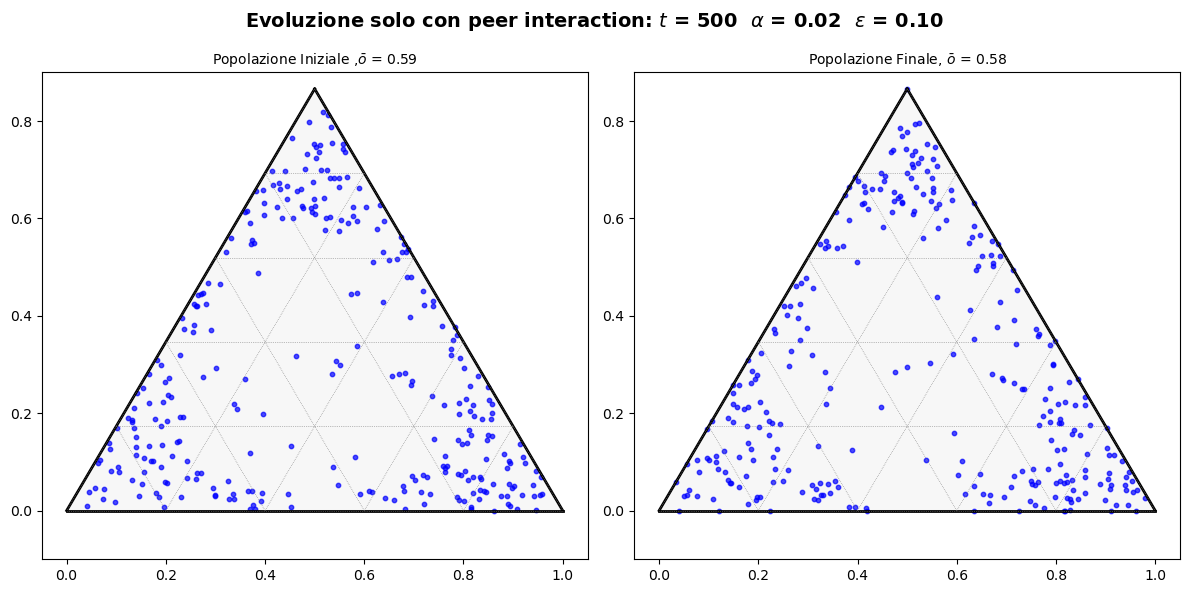

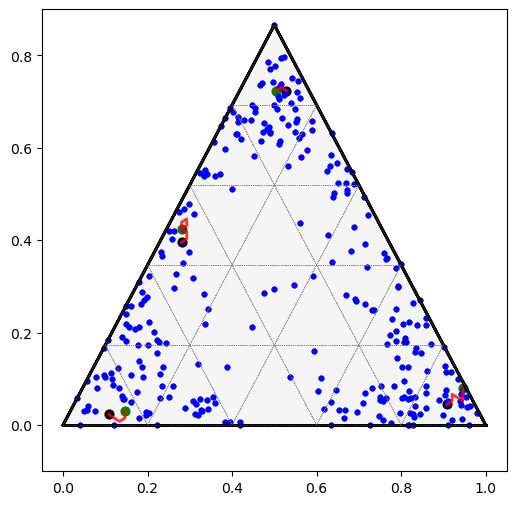

FINAL COHESION VALUE 0.569140586472142


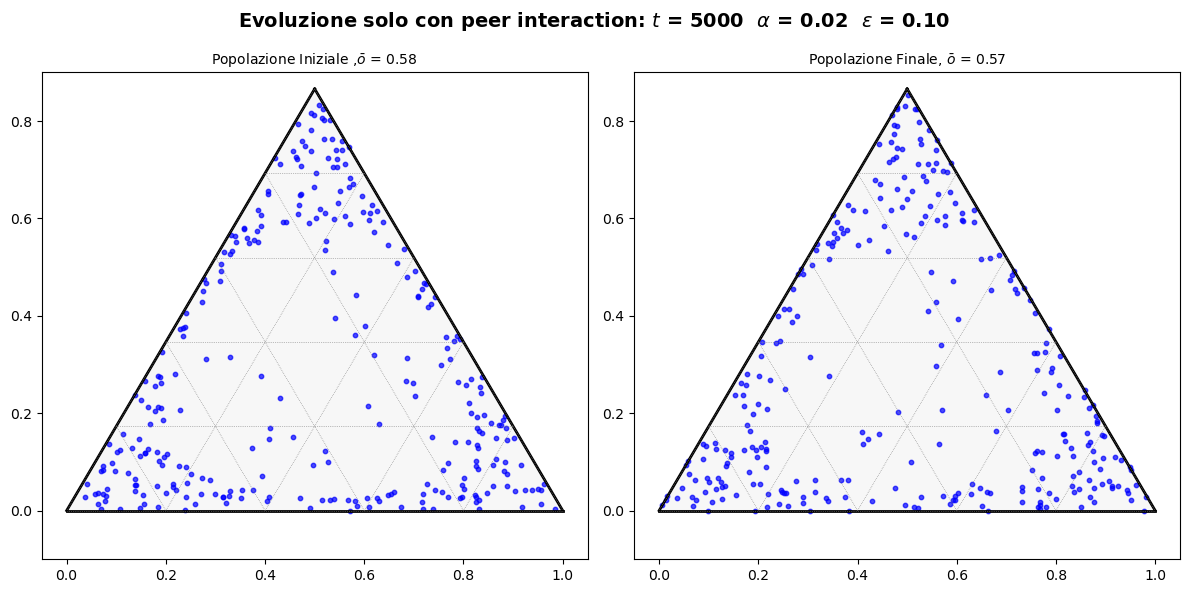

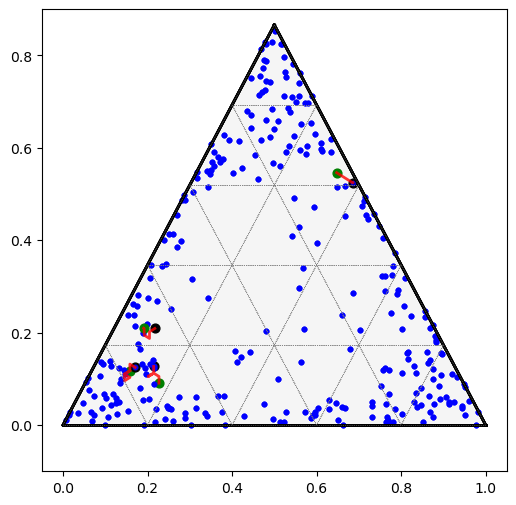

FINAL COHESION VALUE 0.5763854557985383


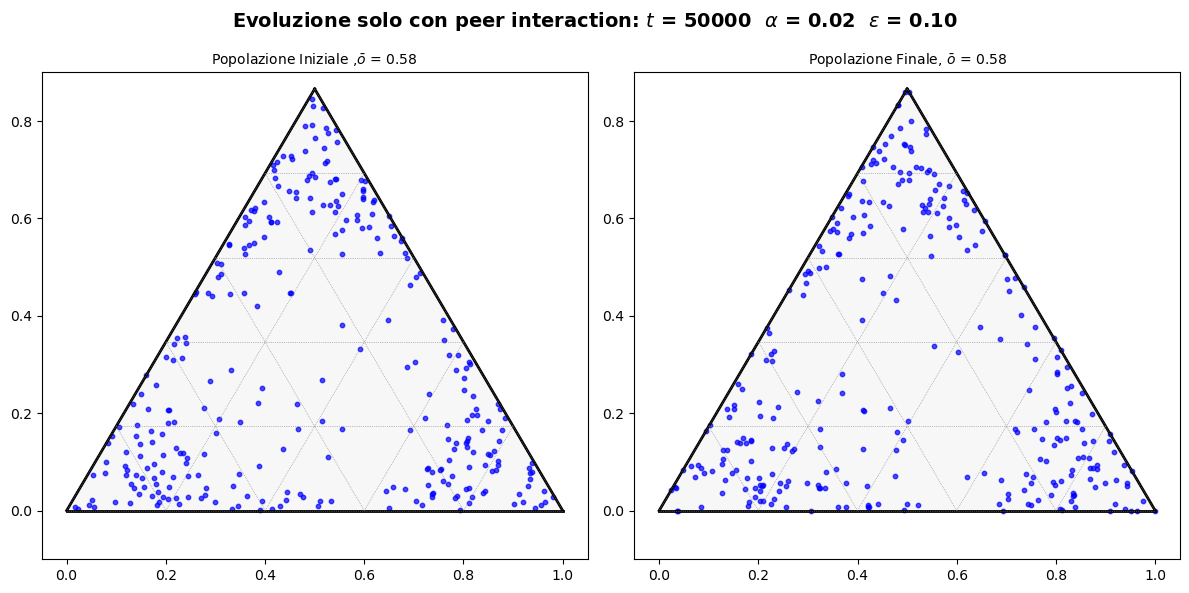

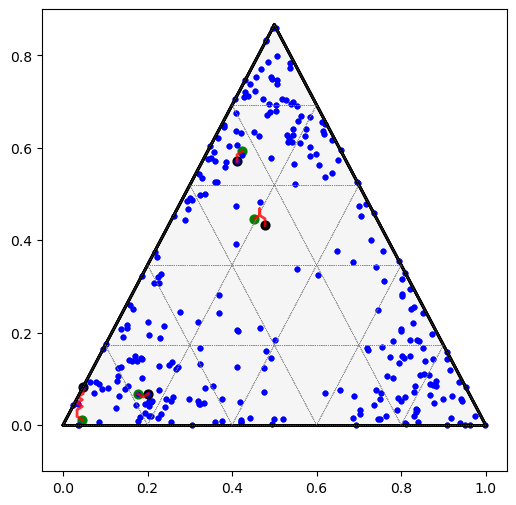

In [6]:
eps = 0.1
for time in [500, 5000, 50000]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6)) 
    popolazione_iniziale = generate_population(K,N, entropy_threshold)
    o = calculate_total_overlap(popolazione_iniziale)
    plt.suptitle(rf"Evoluzione solo con peer interaction: $t$ = {time}  $\alpha$ = {alpha:.2f}  $\epsilon$ = {eps:.2f} ", fontsize=14,  fontweight='bold')

    plot_simplesso_with_ax(popolazione_iniziale, axes[0], rf"Popolazione Iniziale ,$\bar{{o}}$ = {o:.2f}")
    pop_evoluta, storico, storico_interaction=evolve_population( popolazione_iniziale , t , eps, alpha ,mu)

    
    final_o =  calculate_total_overlap(pop_evoluta)
    title = f'traiettoria'

    print('FINAL COHESION VALUE' , final_o )
    plot_simplesso_with_ax(pop_evoluta, axes[1], rf"Popolazione Finale, $\bar{{o}}$ = {final_o:.2f}")
    plt.tight_layout()
    plt.show()
    fig, ax = plt.subplots(figsize=(6, 6))
    index_user = 3 # Cambia questo per tracciare un altro individuo
    plot_user_trajectory_from_dict(storico, index_user, ax)
    plot_user_trajectory_from_dict(storico, 10, ax)
    plot_user_trajectory_from_dict(storico, 205, ax)
    plot_user_trajectory_from_dict(storico, 50, ax)
    
    plt.show()

# PARTE DI CLUSTERING -> OK FUNZIONA, ho controllato anche al variare di mu che desse sempre lo stesso risultato  

In [7]:
high_overlap = 2.2
low_overlap = 1.65

pop_high = generate_population(5 , 300, high_overlap)
pop_low =  generate_population(5 , 300, low_overlap) 

pop_finale_high, storico, storico_int_high = evolve_population( pop_high , 100000 , 0.1, 0.01 ,800)
pop_finale_low , storico , storico_int_low =evolve_population( pop_low  , 100000 , 0.1, 0.01 , 800)


In [2]:
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_cumulative_om(interaction_dict):
    all_times = set()
    om_counter = defaultdict(int)
    
    for individuo, tempi in interaction_dict.items():
        for tempo, interazioni in tempi.items():
            all_times.add(tempo)
            for interazione in interazioni:
                if interazione[0] == 'om':  # Tipo OM
                    om_counter[tempo] += 1

    # Ordina i tempi e calcola il cumulativo
    sorted_times = sorted(all_times)
    cumulative = 0
    cumulative_counts = []
    
    for t in sorted_times:
        cumulative += om_counter.get(t, 0)
        cumulative_counts.append(cumulative)

    # Crea il grafico
    plt.figure(figsize=(12,6))
    plt.step(sorted_times, cumulative_counts, where='post', color='b')
    plt.title('Conteggio cumulativo interazioni Open-Minded')
    plt.xlabel('Tempo')
    plt.ylabel('Totale interazioni OM')
    plt.grid(True)
    plt.show()

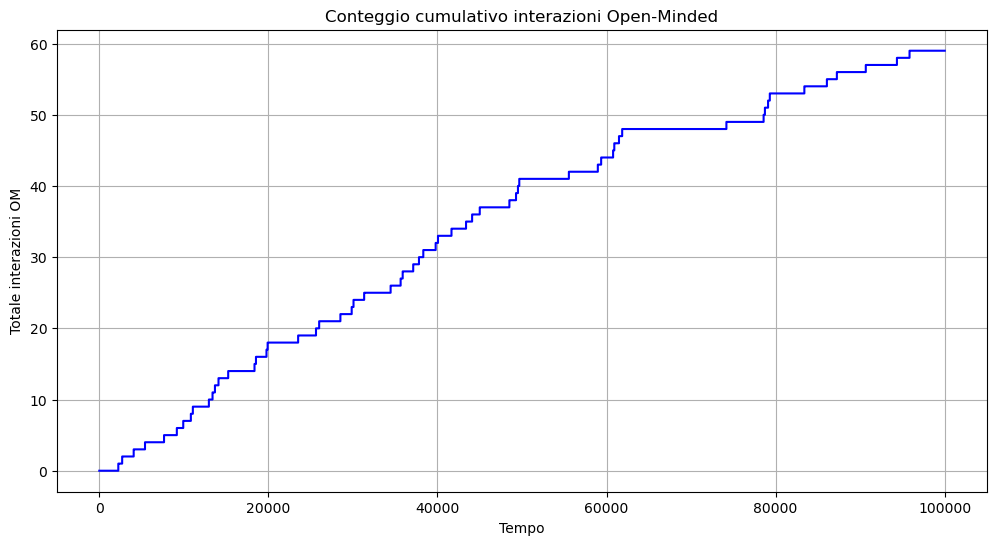

In [9]:
plot_cumulative_om(storico_int_high)

In [10]:
labels_high = hierarchical_clustering_K(pop_finale_high, similarity_threshold=0.8)
labels_low  = hierarchical_clustering_K(pop_finale_low, similarity_threshold=0.8)


pr_high = compute_PR(labels_high)
pr_low  = compute_PR(labels_low)

print("PR high:", pr_high)  # Ci si aspetta PR ≈ 1
print("PR low:", pr_low)    # Ci si aspetta PR ≈ K 

PR high: 1.1064394777605664
PR low: 4.483858110801116


In [11]:
### SEGNALIBRO : ho messo un w = 1 per vedere che succedeva quindi cambialo!!! 

### ORA DEVO AGGIUNGERE LA MODULATED INFORMATION 

In [5]:
PI = 0.5
K = 5
mu = 200
eps = 0.1
alpha = 0.01
time = 100000
pop_iniz = generate_population( K ,300, 2.2)

In [6]:
a_s = []
PR_low = []
for a_ in np.arange(0.2, 1, 0.1): 
    a_s.append(a_)
    I = external_info(K,a_)
    pop_finale   , storico  , storico_interaction =  evolve_population_with_info_and_peer_openm( pop_iniz , time , eps, alpha , I , PI , mu)
    labels  = hierarchical_clustering_K(pop_finale, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_low.append(pr)
    print('PR for a = ', a_, 'is PR= ', pr)

PR for a =  0.2 is PR=  1.0
PR for a =  0.30000000000000004 is PR=  1.0
PR for a =  0.4000000000000001 is PR=  1.0
PR for a =  0.5000000000000001 is PR=  1.0
PR for a =  0.6000000000000001 is PR=  3.251680034684587
PR for a =  0.7000000000000002 is PR=  4.855940433797345
PR for a =  0.8000000000000003 is PR=  4.805125467164976
PR for a =  0.9000000000000001 is PR=  4.862236628849271


In [ ]:

# a_s = [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
# PR_low = [1.0340311128472621, 1.0 ,1.0, 1.0 ,  3.514252245216712,4.979528604625429,4.964147821290679, 4.9977787649933365]
 

# Triggering consensus through moderate information

In [7]:
PI = 0.5
K = 5
mu = 200
eps = 0.1
alpha = 0.01
PR_HIGH = []
time = 100000
pop_iniz = generate_population( K ,300, 1.65)
for a_ in np.arange(0.2, 1, 0.1): 
    I = external_info(K,a_)
    
    pop_finale_low , storico , storico_int = evolve_population_with_info_and_peer_openm( pop_iniz , time , eps, alpha , I , PI , mu)
    labels  = hierarchical_clustering_K(pop_finale_low, similarity_threshold=0.8)
    pr = compute_PR(labels)
    PR_HIGH.append(pr)
    print('PR for a = ', a_, 'is PR= ', pr)

PR for a =  0.2 is PR=  1.0918354967851511
PR for a =  0.30000000000000004 is PR=  1.0
PR for a =  0.4000000000000001 is PR=  1.0
PR for a =  0.5000000000000001 is PR=  1.0
PR for a =  0.6000000000000001 is PR=  3.5976974736168854
PR for a =  0.7000000000000002 is PR=  4.94668572056722
PR for a =  0.8000000000000003 is PR=  4.932587964485367
PR for a =  0.9000000000000001 is PR=  4.949406071271447


In [8]:
# salviamo i valori: 
# a_s = [0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
# pr_high = [ 4.914273233591787, 4.880164841123523,4.8754062838569885, 4.979528604625429, 4.975674480318443, 4.94668572056722, 4.776562997558646, 4.960864292801235  ]

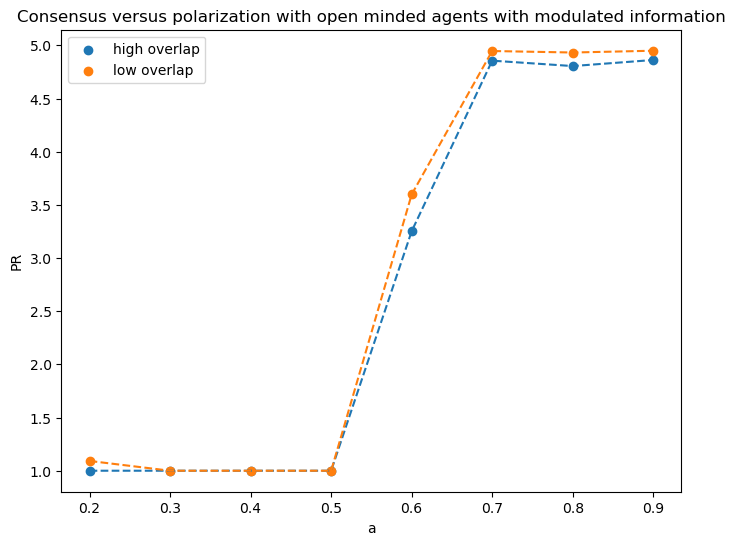

In [9]:
plt.figure(figsize=(8, 6))
plt.plot(a_s , PR_low , '--')
plt.scatter(a_s , PR_low , label = 'high overlap')
plt.scatter(a_s , PR_HIGH, label = 'low overlap')
plt.plot(a_s , PR_HIGH , '--' )
plt.xlabel('a')
plt.title('Consensus versus polarization with open minded agents with modulated information')
plt.legend()
plt.ylabel('PR')
plt.show()

# VEDIAMO L'EURISTICA DELLA MATRICE DI INTERAZIONE PRENDENDO I DATI DAL DIZIONARIO DELLO STORICO DELLE INTERAZIONI 

In [ ]:
import numpy as np

def tipo_interazione_numerico(tipo):
    if tipo == 'om':
        return 0
    return tipo  # +1 o -1

def costruisci_matrice_interazioni(dizionario):
    # Raccogli tutti gli individui coinvolti come mittente o destinatario
    individui = set(dizionario.keys())
    for interazioni in dizionario.values():
        for lista_eventi in interazioni.values():
            for _, _, destinatario in lista_eventi:
                individui.add(destinatario)
    
    individui = sorted(individui)
    id2idx = {id_: idx for idx, id_ in enumerate(individui)}
    N = len(individui)
    
    somma_interazioni = np.zeros((N, N))
    conteggio_interazioni = np.zeros((N, N))
    
    for mittente, interazioni in dizionario.items():
        for eventi in interazioni.values():
            for tipo, _, destinatario in eventi:
                i = id2idx[mittente]
                j = id2idx[destinatario]
                tipo_num = tipo_interazione_numerico(tipo)
                somma_interazioni[i, j] += tipo_num
                conteggio_interazioni[i, j] += 1

    with np.errstate(divide='ignore', invalid='ignore'):
        matrice_media = np.true_divide(somma_interazioni, conteggio_interazioni)
        matrice_media[conteggio_interazioni == 0] = np.nan
    
    return matrice_media, individui


In [ ]:
int_matrix_high , individui_high = costruisci_matrice_interazioni(storico_int_high)

In [ ]:
def categorizza_interazioni(matrice):
    """
    Input:
      matrice: numpy.ndarray di shape (N, N), dtype float,
               con np.nan dove non ci sono interazioni
    Output:
      numpy.ndarray di shape (N, N), dtype object,
      con valori "F", "E", "OM" o np.nan
    """
    # Creiamo un array di oggetti per tenere stringhe e nan
    cat = np.empty(matrice.shape, dtype=object)
    
    # Maschere
    nan_mask = np.isnan(matrice)
    pos_mask = matrice >  0.1
    neg_mask = matrice < -0.1
    om_mask  = (~nan_mask) & (~pos_mask) & (~neg_mask)
    
    # Assegniamo
    cat[nan_mask] = np.nan
    cat[pos_mask] = "F"
    cat[neg_mask] = "E"
    cat[om_mask]  = "OM"
    
    return cat

In [ ]:
matrice_interazioni = categorizza_interazioni(int_matrix_high)

In [ ]:
import pandas as pd
def verifica_euristica(cat):

    N = cat.shape[0]
    match = 0
    totale = 0
    
    for i in range(N):
        for j in range(N):
            a = cat[i, j]
            if a not in ("F", "E"):
                continue
            for k in range(N):
                b = cat[j, k]
                c = cat[i, k]
                # Prendo solo se a e b sono F/E e c non è nan
                if b in ("F", "E") and not pd.isna(c):
                    # euristica
                    expected = "F" if a == b else "E"
                    totale += 1
                    if c == expected:
                        match += 1
    
    percentuale = (match / totale * 100) if totale > 0 else np.nan
    return percentuale, match, totale


In [ ]:
pct, m, t = verifica_euristica(matrice_interazioni)
print(f"Conferma euristica in {m}/{t} casi → {pct:.2f}%")

In [ ]:
def verifica_euristica_friend_focused(cat):
    N = cat.shape[0]
    match = 0
    totale = 0
    
    for i in range(N):
        for j in range(N):
            a = cat[i, j]
            # Considero solo i→j = F
            if a != "F":
                continue
            
            for k in range(N):
                b = cat[j, k]
                c = cat[i, k]
                # b deve essere F o E, c non deve essere nan
                if b in ("F", "E") and not pd.isna(c):
                    # euristica friend-focused
                    expected = "F" if b == "F" else "E"
                    totale += 1
                    if c == expected:
                        match += 1
    
    percentuale = (match / totale * 100) if totale > 0 else np.nan
    return percentuale, match, totale